# 기술통계 실습

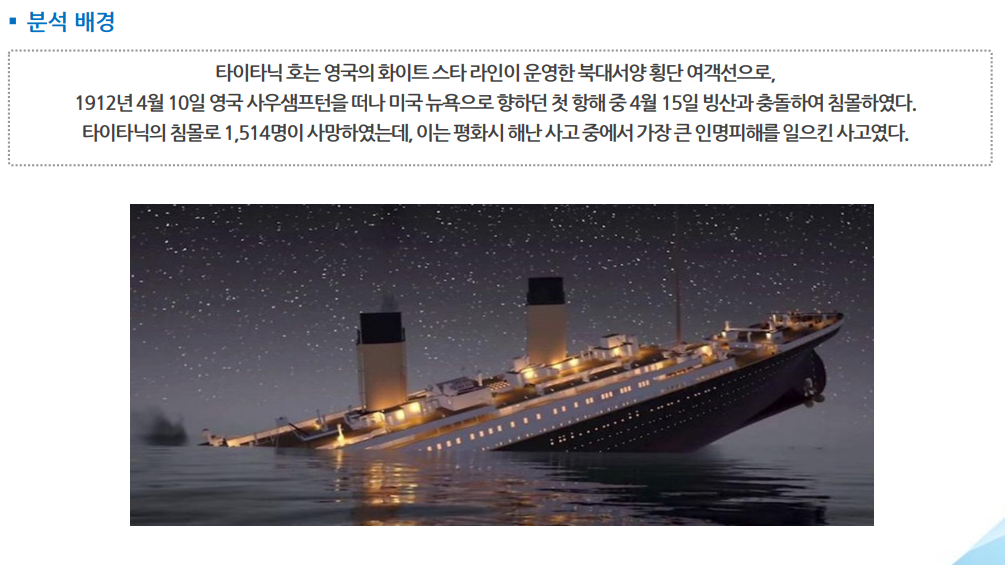

#### 1. 개요
1912년 발생한 타이타닉호 침몰 사고는 역사상 가장 비극적인 해난 사고 중 하나입니다. 본 분석에서는 당시 탑승객의 데이터를 바탕으로 어떤 요인이 생존에 결정적인 영향을 미쳤는지 확인하고 가설을 검증해 봅니다.

#### 2. 가설
[신분] 높은 등급의 객실에 머문 승객일수록 생존율이 높았을 것이다.

[교전] 당시 구조 원칙에 따라 여성과 어린아이의 생존율이 남성보다 높았을 것이다.

[비용] 더 높은 운임을 지불한 승객이 구조에 유리한 위치에 있었을 것이다.

In [2]:
# 데이터 구성 패키지:Series, DataFrame
import pandas as pd
# 행렬 연산 패키지
import numpy as np

# 실행결과 경고메시지 출력 제외
import warnings
warnings.filterwarnings('ignore')

# 데이터 시각화 패키지
import matplotlib
import matplotlib.pyplot as plt

# 데이터 시각화(추세 등) 패키지
import seaborn as sns

# 그래프 표시
%matplotlib inline

In [3]:
# 한글과 음수 표시
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus = False)

In [4]:
# titanic.csv 가져오기
df = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\titanic.csv", encoding='euc-kr')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### STEP ❶ : 데이터 속성 및 기술통계량 확인

In [5]:
# 데이터 상위 5행 확인
print('=== 상위 5행 ===' )
df.head()

=== 상위 5행 ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# 데이터 기본 정보 확인 # 열의 속성 확인
print('=== 데이터 정보 ===')
df.info()

=== 데이터 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# 기술통계량 확인
print('=== 기술통계량 ===')
df.describe(include='all')      # 옵션: include='all' = 수치형 변수(평균/표준편차)와 범주형(최빈값/빈도수) 변수를 모두 포함

=== 기술통계량 ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.758889,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,13.002570,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,22.000000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,30.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,35.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


### 변수 정의 및 분류
1. **목표 변수 (Target Variable)** : 분석이나 예측 모델을 통해 최종적으로 알고자 하는 결과값입니다
   - 변수명: Survived(생존여부)


2. **설명 변수 (Explanatory Variable)**:  목표 변수에 영향을 주는 원인이나 조건이 되는 변수들입니다.
   - 범주형: Pclass, Sex, Embarked
   - 연속형: Age, SibSp, Parch, Fare

3. **기타 변수** (분석 목적에 따라 제외하거나 별도의 가공이 필요한 변수)
   - PassengerId, Name, Ticket, Cabin


### STEP ❷ : 목표변수 및 설명변수(범주형/연속형 변수별)의 분포 확인

#### **목표 변수(Survived)** 분포 확인 : 살았나(1) 죽었나(0) 확인

Text(0.5, 1.0, 'Distribution of Survived')

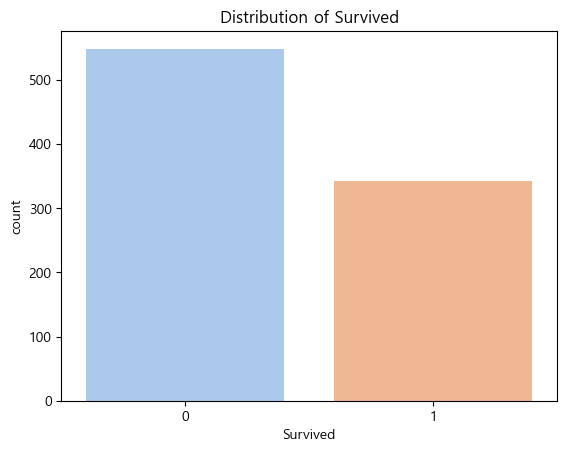

In [8]:
sns.set_palette("pastel")       # 파스텔 ~
sns.countplot(x='Survived',  data=df)
plt.title('Distribution of Survived')

#### **범주형 설명 변수** 확인 (Pclass, Sex, Embarked)

([<matplotlib.axis.XTick at 0x1d9e265add0>,
 [Text(0, 0, 'First'), Text(1, 0, 'Second'), Text(2, 0, 'Third')])

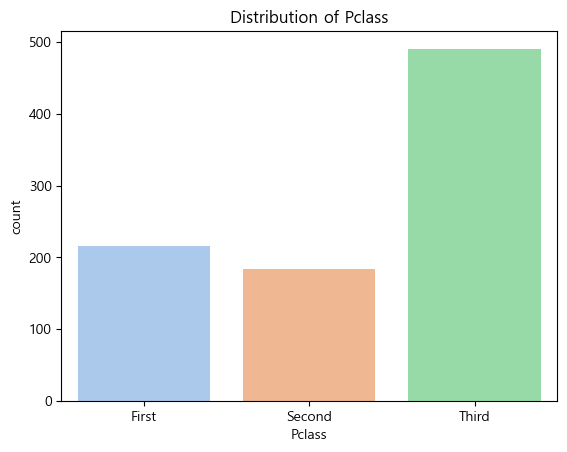

In [9]:
sns.set_palette("pastel")

# Pclass
sns.countplot(x='Pclass', data=df)
plt.title('Distribution of Pclass')

# 축 이름이 첫번째 인덱스 순서대로 1, 2, 3 이 나옴, 추측으로 퍼스트, 세컨드, 서드로 변경
plt.xticks([0, 1, 2], ['First', 'Second', 'Third'])



Text(0.5, 1.0, 'Distribution of Sex')

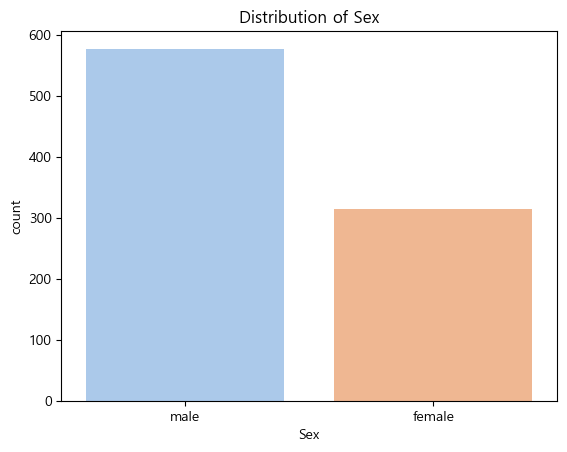

In [10]:
sns.set_palette("pastel")

# PclSexss
sns.countplot(x='Sex', data=df)
plt.title('Distribution of Sex')


([<matplotlib.axis.XTick at 0x1d9e5caae90>,
 [Text(0, 0, 'Southampton'),
  Text(1, 0, 'Cherbourg'),
  Text(2, 0, 'Queenstown')])

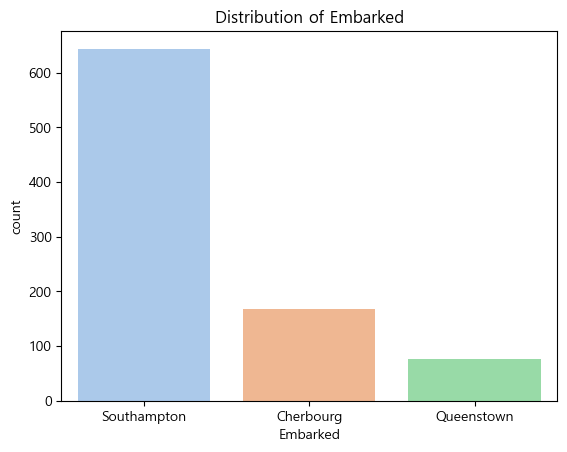

In [11]:
sns.set_palette("pastel")

# Embarked
sns.countplot(x='Embarked', data=df)
plt.title('Distribution of Embarked')

# 축 이름이 첫번째 인덱스 순서대로 S, C, Q 가 나옴, 추측으로 Southampton, Cherbourg, Queenstown로 변경
plt.xticks([0, 1, 2], ['Southampton', 'Cherbourg', 'Queenstown'])



##### Embarked(승선 항구) 분포 확인 결과, 영국 사우샘프턴(S) 승객이 가장 많았으며 이는 타이타닉호의 실제 출발지 및 항로 기록과 일치한다. 실제로 타이타닉호는 영국 사우샘프턴을 출발지로 하여 프랑스 셰르부르, 아일랜드 퀸즈타운을 순차적으로 경유하였다고한다.

#### **연속형 설명 변수** 확인 (Age, Fare, SibSp, Parch)

Text(0.5, 1.0, 'Age Distribution')

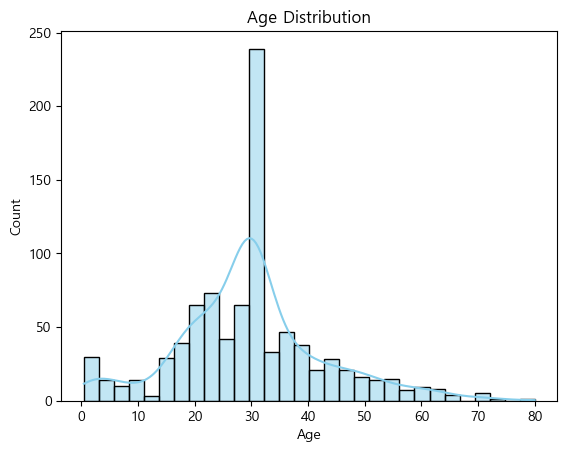

In [12]:
# sns.histplot(df['Age'].dropna(), kde=True, color='skyblue')   
sns.histplot(data=df, x="Age", kde=True, color='skyblue')         # 하늘색 좋아합니다. 그리고 선 한 번 그어봤어용
plt.title('Age Distribution')

Text(0.5, 1.0, 'Fare Distribution')

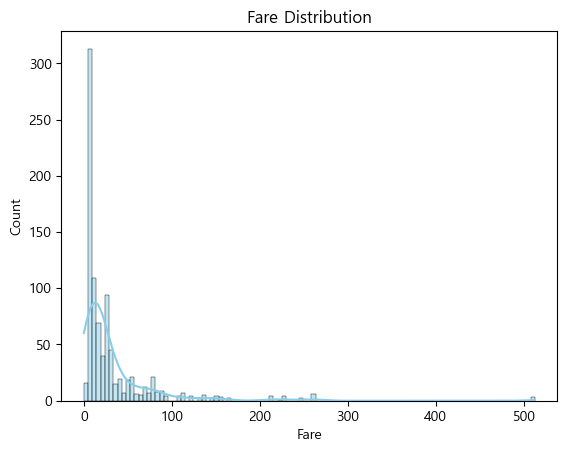

In [13]:
sns.histplot(data=df, x="Fare", kde=True, color='skyblue')      # 하늘색 좋아합니다. 그리고 선 한 번 그어봤어용
plt.title('Fare Distribution')

##### SibSp, Parch는 수치형이지만 값이 이산적(0, 1, 2...)이므로, 
##### 전체 흐름(Histogram)과 개별 빈도(Count Plot)를 다각도로 비교 분석하기 위해 두 그래프를 병행함

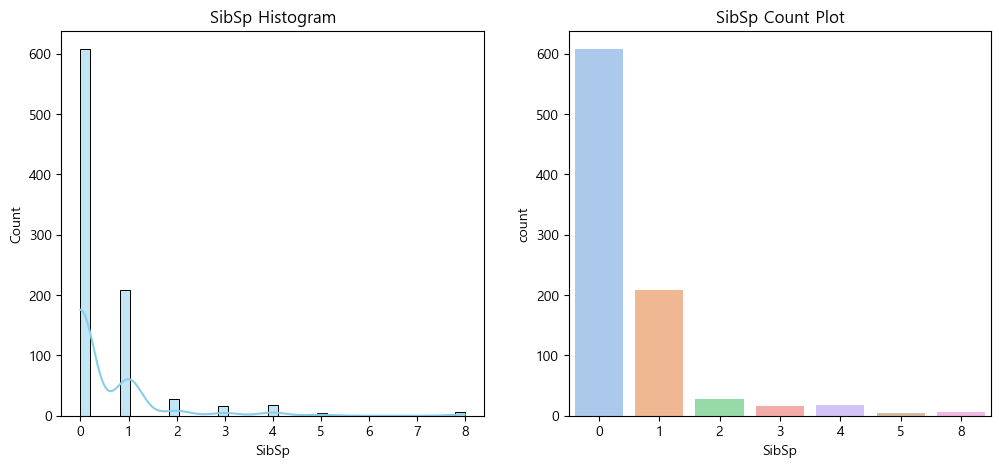

In [14]:
plt.figure(figsize=(12, 5))     # 크기 설정 : (가로 12, 세로 5 비율)

# 1. 왼쪽: 히스토그램 (흐름 파악용)
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='SibSp', kde=True, color='skyblue')
plt.title('SibSp Histogram')

# 2. 오른쪽: 카운트플롯 (정확한 개수 확인용)
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='SibSp', palette='pastel')
plt.title('SibSp Count Plot')


plt.show()

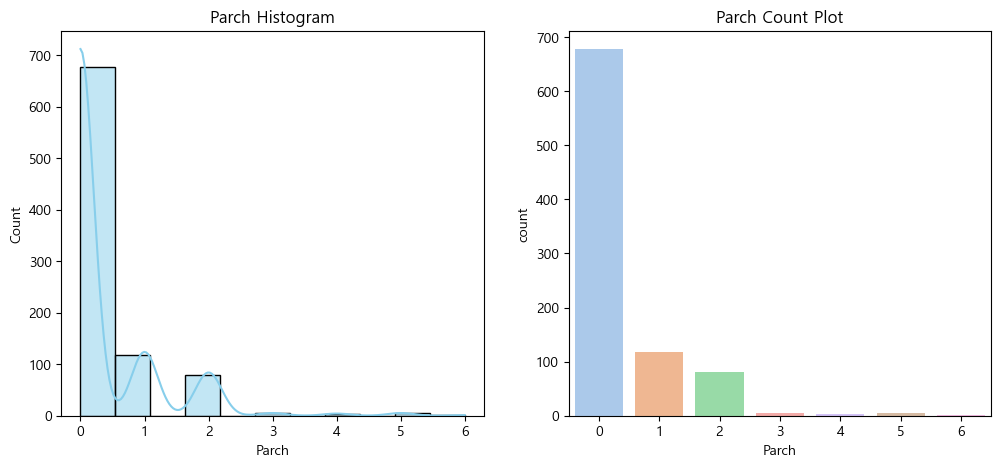

In [15]:
plt.figure(figsize=(12, 5))     # 크기 설정 : (가로 12, 세로 5 비율)

# 1. 왼쪽: 히스토그램 사용함
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Parch', kde=True, color='skyblue')
plt.title('Parch Histogram')

# 2. 오른쪽: 카운트플롯 사용함
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Parch', palette='pastel')
plt.title('Parch Count Plot')


plt.show()

### STEP ❸ : 변수들의 결측 및 이상치 처리  (126 Page)

### **데이터 정제(Data Cleaning) 단계**
🔻진찰 결과를 바탕으로 실제로 데이터를 수정함.

🔻결측치 처리: fillna() 등을 사용해 구멍을 메움.

🔻이상치 처리: 너무 튀는 값을 제거하거나 보정함.

🔻불필요한 컬럼 삭제: 분석에 필요 없는 PassengerId, Ticket 등을 버림.


#### 1. 결측치(Missing Value) 처리를 하는 이유
- **분석의 무결성 유지**: 대부분의 머신러닝 알고리즘은 결측치가 포함된 데이터를 학습할 수 없으므로, 데이터의 손실을 최소화하면서 모델이 작동할 수 있는 형태로 보완해야 함.

- **통계적 왜곡 방지**: 데이터가 비어 있는 상태로 분석을 진행하면 평균, 분산 등 통계값이 왜곡되어 잘못된 인사이트를 도출할 위험이 있음.

- **정보의 가치 보존**: 결측치가 있는 행을 단순히 삭제하기보다는 적절한 값(중앙값, 최빈값 등)으로 대체함으로써 샘플 수를 유지하고 데이터의 정보 가치를 보존함.

#### 2. 이상치(Outlier) 처리를 하는 이유
- **모델의 성능 향상**: 요금(Fare) 데이터의 초고가 티켓처럼 일반적인 범위를 벗어난 값은 모델을 편향되게 학습시켜 예측력을 떨어뜨릴 수 있음.

- **분석 결과의 신뢰도 확보**: 이상치는 평균 등 통계지표를 실제보다 높거나 낮게 왜곡하므로, 이를 식별하고 처리(삭제 혹은 대체)하여 데이터의 대표성을 확보함.

### 결측치 확인

In [16]:
# 결측치 확인
print("--- 결측치 확인 ---")
df.isnull().head()

--- 결측치 확인 ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False


In [17]:
# 결측치 확인 isnull()과 동일함 
print("--- 결측치 확인 ---")
df.isna().head(3)

--- 결측치 확인 ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False


In [18]:
# 결측치 빈도 집계
print("--- 결측치 개수 확인 ---")
df.isnull().sum()

--- 결측치 개수 확인 ---


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 결측치 상황:  

Cabin (객실 번호): 687개 (전체 데이터의 약 77%)

Embarked (승선 항구): 2개

In [19]:
# '결측치가 많은 변수 제외' 원칙 적용
df.drop(columns=['Cabin'], inplace=True)

# ----------- 보존도 가능 ------------
# # 결측치를 'N'이라는 새로운 범주로 대체
# df['Cabin'] = df['Cabin'].fillna('N')

In [20]:
# Embarked: 최빈값인 'S'로 채우기
df['Embarked'].fillna("S", inplace=True)


# df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

### 이상치 확인

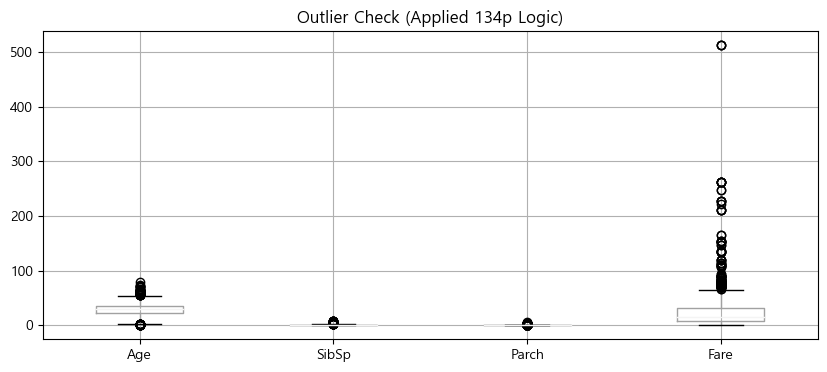

In [21]:
# 타이타닉 데이터는 단위 분리가 필요 없으므로 str.split 단계는 생략함

df[['Age', 'SibSp', 'Parch', 'Fare']].boxplot(figsize=(10, 4))

plt.title('Outlier Check (Applied 134p Logic)')
plt.show()

종합 Boxplot 확인: 전체 수치형 변수를 시각화한 결과, 변수 간 스케일 차이가 뚜렷하며 특히 Fare 변수에서 극단적인 이상치가 다수 관찰됨.

특이 사항: Fare의 경우 500달러를 상회하는 데이터가 존재하며, 이는 평균치를 왜곡할 가능성이 큼. Age 변수 역시 고연령대 영역에서 일부 이상치가 식별됨.

인간의 나이는 80대는 그럴 수 있음 살려두도록 하고 이상치가 아닌 것 같다는 판단!!!  

Fare가 문제임 !!!

In [22]:
# Fare가 500 이상인 데이터 직접 확인 
outliers = df[df['Fare'] >= 500]
display(outliers)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C


3명 발견, 가족인가봄, 동일한 요금/티켓/등급/항구, 전원 생존함

역사적 사실 유지보다 그냥 없애겠음

In [23]:
# 1. Fare가 500 미만인 자료만 살리기 (3명 삭제될 예정)
df = df[df["Fare"] < 500]



In [24]:
# 2. 인덱스 초기화
df.reset_index(drop=True, inplace=True)

print("--- 이상치 제거 후 데이터 정보 ---")
print(f"남은 데이터 수: {len(df)}개") 
df.head()

--- 이상치 제거 후 데이터 정보 ---
남은 데이터 수: 888개


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [25]:
# 전체 요약 정보(메타데이터)를 출력하는 명령어
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 888 entries, 0 to 887
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  888 non-null    int64  
 1   Survived     888 non-null    int64  
 2   Pclass       888 non-null    int64  
 3   Name         888 non-null    object 
 4   Sex          888 non-null    object 
 5   Age          888 non-null    float64
 6   SibSp        888 non-null    int64  
 7   Parch        888 non-null    int64  
 8   Ticket       888 non-null    object 
 9   Fare         888 non-null    float64
 10  Embarked     888 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.4+ KB


#### 위에 했던 결과 가져옴
=== 데이터 정보 ===  

<class 'pandas.core.frame.DataFrame'>  

RangeIndex: 891 entries, 0 to 890  

Data columns (total 12 columns):  


891개였음 -> 정제 -> 888개

### STEP P ❹ : 그래프 분석을 통해 변수간 관계를 확인

#### 데이터 변환 (Data Transformation) 단계

🔻머신러닝 모델이 학습할 수 있도록 데이터를 수치 형태로 가공함.

🔻범주형 데이터 인코딩: "male/female", "S/C/Q" 같은 문자열을 0, 1, 2 등의 숫자로 변환함.

🔻데이터 타입 변환: 연산이 불가능한 object 타입을 계산이 가능한 수치형(int, float)으로 바꿈.

🔻파생 변수 생성: 기존의 변수들을 조합하여 분석에 의미 있는 새로운 변수(예: 가족 수 합계)를 만듦.

#### [파생변수 생성 사유: FamilySize]  "같이 대피했을 것 같음"
🔻 데이터의 단순화 및 효율성: 형제/배우자 수(SibSp)와 부모/자녀 수(Parch)는 모두 '가족 동반'이라는 공통된 성격을 가짐. 이를 개별적으로 분석하기보다 하나의 합계 데이터로 통합하여 모델의 복잡도를 낮추고 효율성을 높임.



In [26]:
# Page 137 참고...
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [27]:
# Page 128.... 불필요한 변수 제거
# 이미 분석에 활용했거나 계산이 불가능한 문자열 제거
df.drop(['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,male,22.0,7.2500,S,2
1,1,1,female,38.0,71.2833,C,2
2,1,3,female,26.0,7.9250,S,1
3,1,1,female,35.0,53.1000,S,2
4,0,3,male,35.0,8.0500,S,1


In [28]:
# 범주형 변수의 Dummy 변수화 : 문자열인 성별과 항구를 숫자로 바꾸기

df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy.head()

,Survived,Pclass,Age,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,7.2500,2,1,0,1
1,1,1,38.0,71.2833,2,0,0,0
2,1,3,26.0,7.9250,1,0,0,1
3,1,1,35.0,53.1000,2,0,0,1
4,0,3,35.0,8.0500,1,1,0,1


In [29]:
df_dummy.describe()

,Survived,Pclass,Age,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S
count,888.000000,888.000000,888.000000,888.000000,888.000000,888.000000,888.000000,888.000000
mean,0.381757,2.313063,29.740056,30.582164,1.906532,0.647523,0.086712,0.727477
std,0.486091,0.834007,13.020462,41.176366,1.615609,0.478011,0.281571,0.445508
min,0.000000,1.000000,0.420000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,7.895800,1.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,30.000000,14.454200,1.000000,1.000000,0.000000,1.000000
75%,1.000000,3.000000,35.000000,30.771850,2.000000,1.000000,0.000000,1.000000
max,1.000000,3.000000,80.000000,263.000000,11.000000,1.000000,1.000000,1.000000


#### O 분석
#### - Age (나이):

평균이 약 29.7세, 최고령자는 80세 (0~80 숫자 분포)

#### - Fare (요금): 여기!!!!

평균은 30.5, 최대값은 263. --> 이상하다@!!!!



#### - FamilySize (가족 수):

평균은 1.9명 최대는 11명.


#### - Sex_male, Embarked_Q/S:

얘네는 min이 0이고 max가 1입니다. (0 아니면 1인 데이터)

### O 모든 변수의 '체급'을 똑같이 맞추는 작업이 스케일링을 해야함 ( 139 Page )


|방식|특징|비유|
|------|---|---|
|Standard (표준)|데이터를 표준정규분포로 만듦.|가장 무난하고 표준적인 방식|
|Min-Max|모든 값을 0과 1 사이로 압축함.|데이터에 이상치가 없을 때 좋음|
|Robust (강건)|중앙값과 사분위수 사용.|이상치(Outlier)의 영향을 덜 받고 싶을 때|

In [30]:
# 1. StandardScaler 객체 생성

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [31]:
# 2. 스케일 변환: fit_transform 사용

df_scale_std = scaler.fit_transform(df_dummy)
df_scale_std = pd.DataFrame(df_scale_std, columns = df_dummy.columns)

In [32]:
# 3. 스케일 변환 결과 확인 (자료 139p 하단)
print("--- Standard Scale 적용 결과 ---")
display(df_scale_std.head())

--- Standard Scale 적용 결과 ---


,Survived,Pclass,Age,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S
0,-0.785803,0.824123,-0.594788,-0.566959,0.057886,0.737799,-0.308131,0.612056
1,1.272584,-1.575290,0.634739,0.989016,0.057886,-1.355382,-0.308131,-1.633836
2,1.272584,0.824123,-0.287406,-0.550557,-0.561424,-1.355382,-0.308131,0.612056
3,1.272584,-1.575290,0.404203,0.547171,0.057886,-1.355382,-0.308131,0.612056
4,-0.785803,0.824123,0.404203,-0.547519,-0.561424,0.737799,-0.308131,0.612056


In [33]:
# 4. 요약 통계량 확인: 모든 변수의 평균=0, 표준편차=1 확인 (자료 139p 우측).
print("\n--- 변환 데이터 요약 통계량 (평균 0, 표준편차 1 확인) ---")
display(df_scale_std.describe().round(3))


--- 변환 데이터 요약 통계량 (평균 0, 표준편차 1 확인) ---


,Survived,Pclass,Age,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S
count,888.000,888.000,888.000,888.000,888.000,888.000,888.000,888.000
mean,-0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-0.786,-1.575,-2.253,-0.743,-0.561,-1.355,-0.308,-1.634
25%,-0.786,-0.376,-0.595,-0.551,-0.561,-1.355,-0.308,-1.634
50%,-0.786,0.824,0.020,-0.392,-0.561,0.738,-0.308,0.612
75%,1.273,0.824,0.404,0.005,0.058,0.738,-0.308,0.612
max,1.273,0.824,3.862,5.648,5.632,0.738,3.245,0.612


##### 1. 평균(mean) 모두 0.000

- 이전: Age는 약 30, Fare도 약 30 등 제각각이었음

- 이후: 모든 변수의 중심점이 0으로 모였습니다. 

##### 2. 표준편차(std) 모두 1.001

- 이전: Fare는 41씩 퍼져 있고, Pclass는 0.8씩 퍼져 있었습니다. 퍼진 정도가 다름

- 이후: 모든 데이터가 평균 0을 기준으로 퍼진 정도(변동성)가 똑같아졌습니다. 체급이 완전히 같아짐

##### 3. 최대값(max)의 범위가 비슷해짐

- 이전: Fare 최대값은 263이었고, FamilySize 최대값은 11이었습니다. (약 24배 차이)

- 이후: Fare max는 5.6, FamilySize max는 5.6

### 세 가지 스케일러를 모두 돌리기 (Page 142)

--- [Fare] 변환 데이터 확인 ---


,Raw,Standard,MinMax,Robust
0,7.250,-0.567,0.028,-0.315
1,71.283,0.989,0.271,2.484
2,7.925,-0.551,0.030,-0.285
3,53.100,0.547,0.202,1.689
4,8.050,-0.548,0.031,-0.280



--- [Fare] 요약 통계량 비교 ---


,Raw,Standard,MinMax,Robust
count,888.000,888.000,888.000,888.000
mean,30.582,0.000,0.116,0.705
std,41.176,1.001,0.157,1.800
min,0.000,-0.743,0.000,-0.632
25%,7.896,-0.551,0.030,-0.287
50%,14.454,-0.392,0.055,0.000
75%,30.772,0.005,0.117,0.713
max,263.000,5.648,1.000,10.865


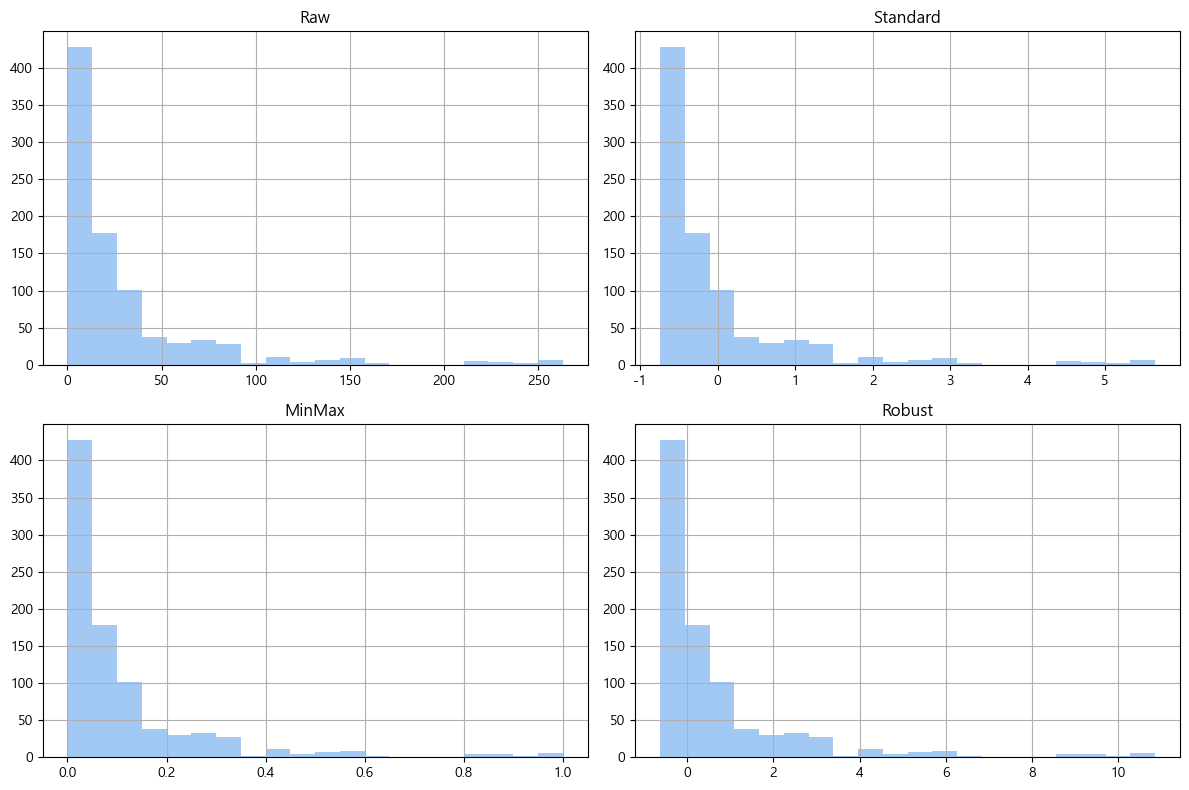

In [34]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 1. 세 가지 스케일링 적용
std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()
rb_scaler = RobustScaler()

# 2. Fare 변수 하나만 골라서 각 방식별로 변환 (자료 142p 로직)
df_fare_compare = pd.DataFrame()
df_fare_compare["Raw"] = df_dummy["Fare"]
df_fare_compare["Standard"] = std_scaler.fit_transform(df_dummy[["Fare"]])
df_fare_compare["MinMax"] = mm_scaler.fit_transform(df_dummy[["Fare"]])
df_fare_compare["Robust"] = rb_scaler.fit_transform(df_dummy[["Fare"]])

# 3. 변환 데이터 확인 및 요약 통계량 (자료 142p 중간 표)
print("--- [Fare] 변환 데이터 확인 ---")
display(df_fare_compare.head().round(3))

print("\n--- [Fare] 요약 통계량 비교 ---")
display(df_fare_compare.describe().round(3))

# 4. 분포 비교 시각화 (자료 142p 하단 히스토그램)
df_fare_compare.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

### STEP 5 들어가기 전, 시각화 분석을 통한 변수 관계 확인

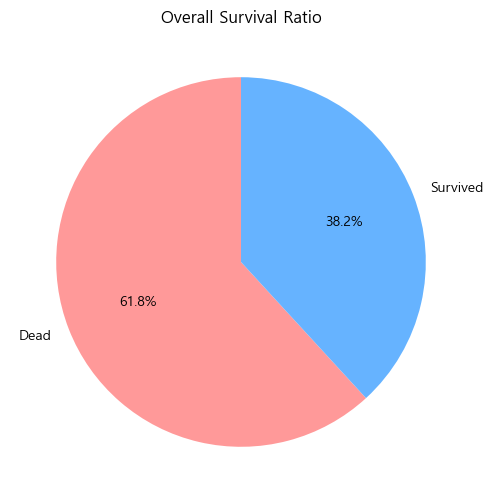

In [35]:
# 생존 여부 비율 확인
plt.figure(figsize=(6, 6))
df['Survived'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, labels=['Dead', 'Survived'], colors=['#ff9999','#66b3ff'])
plt.title('Overall Survival Ratio')
plt.ylabel('') 
plt.show()

#### 1. Pie Chart: 전체 생존 비율 

결과: 사망자(61.8%)가 생존자(38.2%)보다 약 1.6배 더 많습니다.

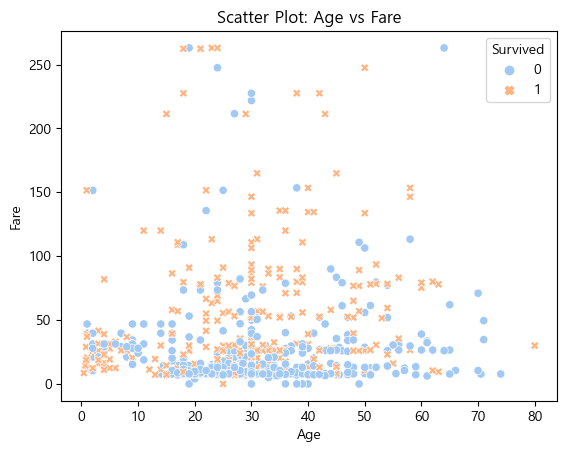

In [36]:

# 나이와 요금의 관계를 생존여부(hue)로 구분해서 그리기
sns.scatterplot(x="Age", y="Fare", hue="Survived", style="Survived", data=df)
plt.title('Scatter Plot: Age vs Fare')
plt.show()

#### 2. Scatter Plot: 나이 vs 요금 

결과: 0에서 250달러까지 점들이 넓게 퍼져 있고, 주황색(생존) 점들이 주로 요금이 높은 쪽에 몰려 있습니다.

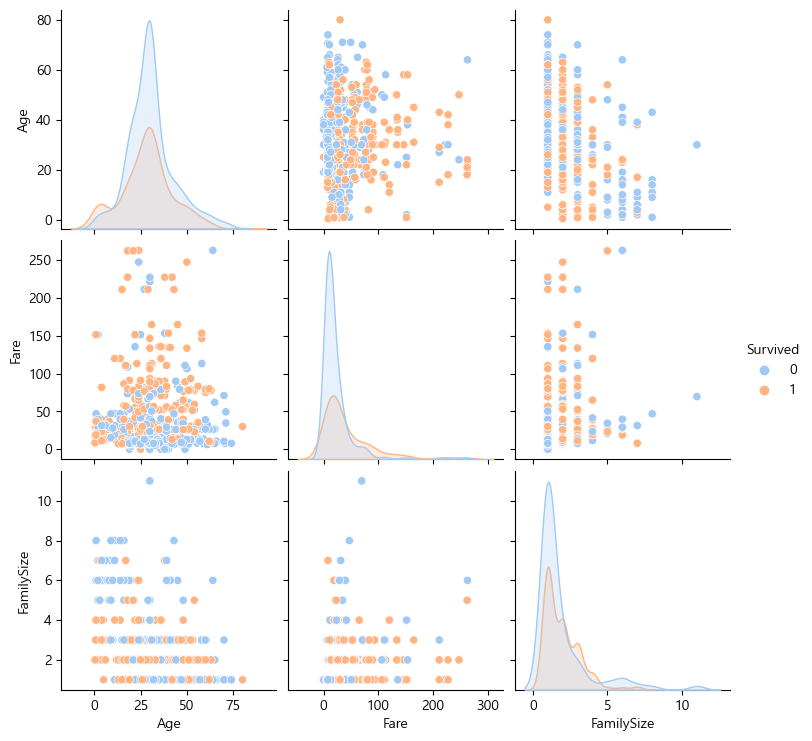

In [37]:
# 수치형 변수들만 골라서 그리기
sns.pairplot(df[['Age', 'Fare', 'FamilySize', 'Survived']], hue="Survived")
plt.show()

#### 3. Pair Plot: 종합 상관성 

결과: 대각선은 분포를, 나머지는 변수 간의 관계를 보여줍니다.

분석: 가운데 Fare 분포를 보면 생존자(주황색)의 요금 곡선이 오른쪽으로 더 길게 뻗어 있습니다. 즉, 비싼 요금을 낸 그룹의 생존 밀도가 더 높음을 시각적으로 증명합니다.

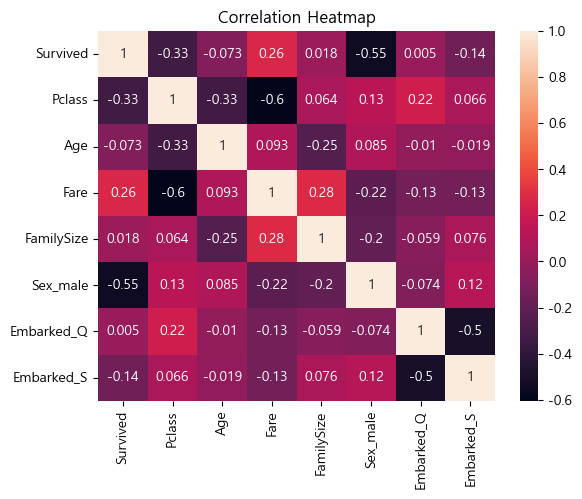

In [38]:
# 가장 기본 옵션만 사용
sns.heatmap(df_dummy.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

#### 4. Heatmap: 상관계수 지도 
결과: Survived와 Sex_male이 -0.55로 가장 강한 음의 상관관계를 보입니다. (남성일수록 생존율이 낮음)  


분석: Survived와 Pclass(-0.33), Fare(0.26) 순으로 상관관계가 높습니다. "성별 > 등급 > 요금" 순으로 생존에 큰 영향을 준다는 결정적 증거가 됩니다.

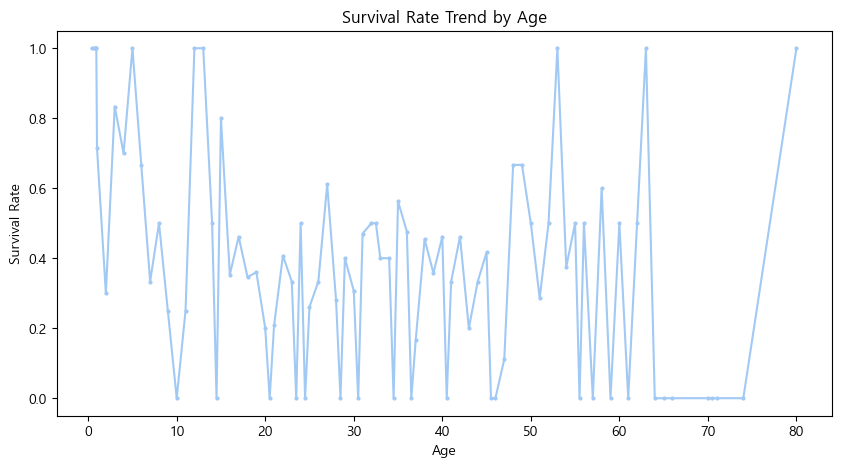

In [39]:
# 연령별 생존율 추세 확인
age_survival = df.groupby('Age')['Survived'].mean()
plt.figure(figsize=(10, 5))
age_survival.plot(kind='line', marker='o', markersize=2)
plt.title('Survival Rate Trend by Age')
plt.ylabel('Survival Rate')
plt.show()

#### 5. Trend Chart: 연령별 생존율 추이 
결과: 0~10세 사이에서 생존율이 급격히 높았다가, 나이가 들수록 변동성이 심해집니다.

분석: "어린아이를 우선 구조했다"

### STEP ❺ : 생존에 영향을 미치는 잠재 인자 도출

 #### 가설 1. 성별에 따른 생존율 차이 (Lady First)
"여성 승객의 생존율이 남성보다 월등히 높을 것이다."

이유: 긴박한 사고 상황에서 어린이와 여성을 우선적으로 구조하는 사회적 원칙이 작용했을 것으로 예상함.

#### 가설 2. 사회경제적 지위에 따른 생존율 차이 (Class Effect)
"높은 등급의 객실 승객일수록 생존율이 높을 것이다."

이유: 1등석 승객은 구명정이 배치된 갑판과 더 가까운 곳에 위치했을 것이며, 경제적 지위가 구조 우선순위에 영향을 주었을 것으로 가정함.

#### 가설 3. 가족 동반 여부 및 규모에 따른 생존율 차이 (Family Size)
"혼자 온 승객보다 가족과 함께 온 승객의 생존율이 높을 것이다.

이유: 가족이 서로를 챙기며 구조를 돕는 긍정적 영향이 있을 것이다.

In [40]:
# 1. 성별 및 객실 등급별 생존율 평균 확인 (가설 검증)
print("--- [가설 검증] 성별 및 등급별 생존율 ---")
display(df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack())

# 2. 가족 수(FamilySize)에 따른 생존율 (파생 변수 통찰)
print("\n--- [파생 변수] 가족 수별 생존율 ---")
family_survival = df.groupby('FamilySize')['Survived'].mean()
display(family_survival)

--- [가설 검증] 성별 및 등급별 생존율 ---


Pclass,1,2,3
Sex,,,
female,0.967742,0.921053,0.500000
male,0.358333,0.157407,0.135447



--- [파생 변수] 가족 수별 생존율 ---


FamilySize
1     0.300935
2     0.550000
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

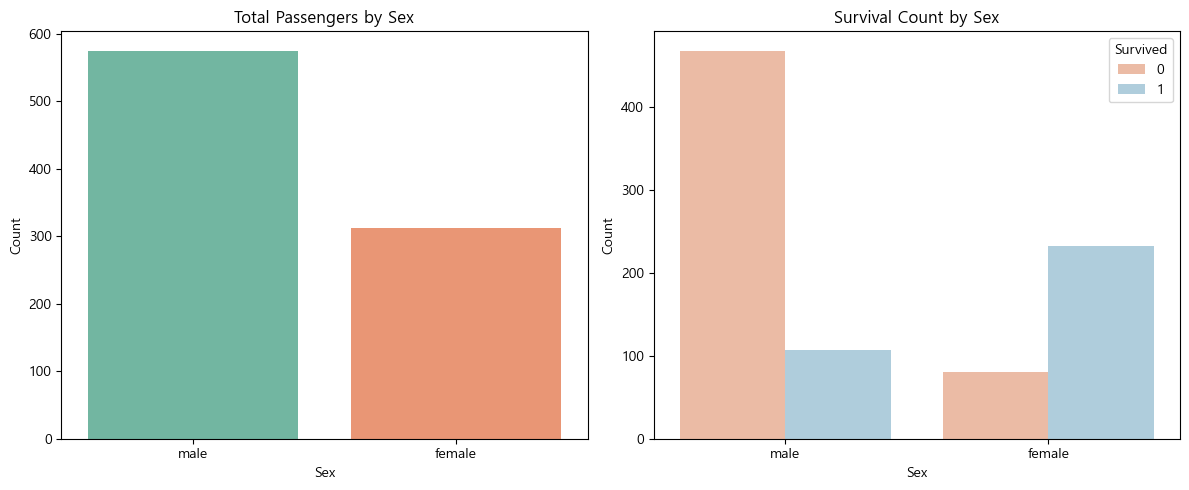

In [41]:
plt.figure(figsize=(12, 5))

# 왼쪽 그래프: 성별 전체 탑승객 수 (Bar Chart)
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Sex', palette='Set2')
plt.title('Total Passengers by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

# 오른쪽 그래프: 성별 생존자 수 (Bar Chart)
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Sex', hue='Survived', palette='RdBu')
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

#####   ⇧   탑승객 수는 남성이 압도적으로 많았으나, 실제 생존자는 여성이 훨씬 많다. 이를 통해 '성별'이 생존을 결정짓는 가장 강력한 잠재 인자임을 시각적으로 증명할 수 있다

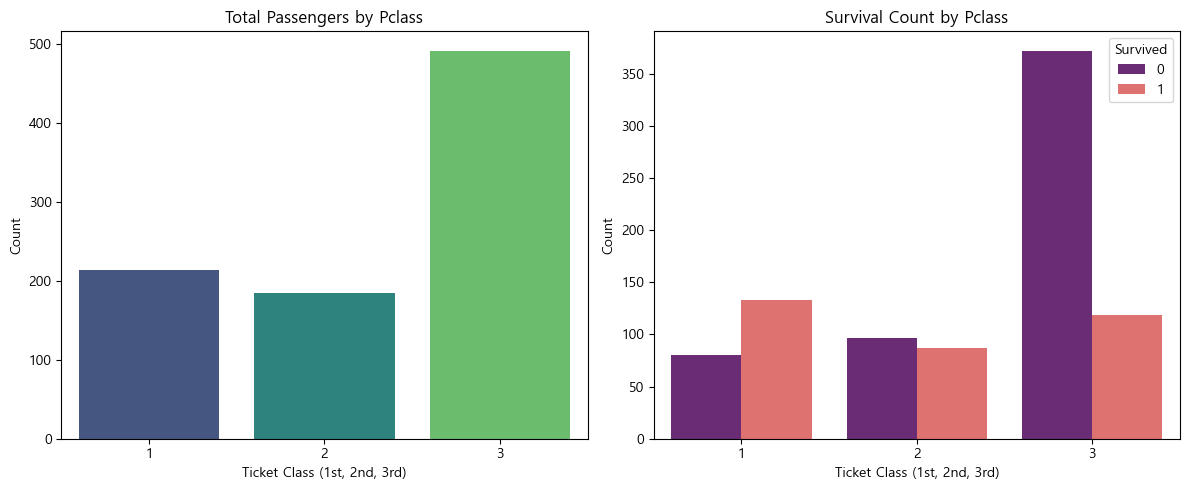

In [42]:

plt.figure(figsize=(12, 5))

# 왼쪽 그래프: 객실 등급별 전체 탑승객 수 (Bar Chart)
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Pclass', palette='viridis')
plt.title('Total Passengers by Pclass')
plt.xlabel('Ticket Class (1st, 2nd, 3rd)')
plt.ylabel('Count')

# 오른쪽 그래프: 객실 등급별 생존/사망자 수 (Bar Chart)
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Pclass', hue='Survived', palette='magma')
plt.title('Survival Count by Pclass')
plt.xlabel('Ticket Class (1st, 2nd, 3rd)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

#### ⇧ 가장 많이 탑승한 그룹은 3등석이었으나, 생존율은 1등석이 가장 높게 나타났다. 이는 객실 등급(사회적 지위)이 생존에 큰 영향을 미친 잠재 인자임을 증명한다

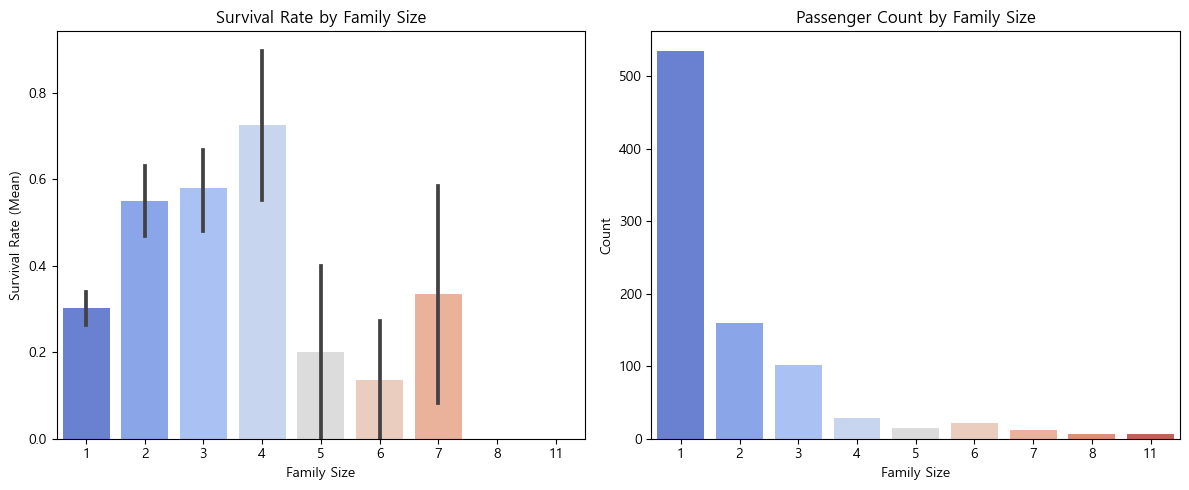

In [43]:
plt.figure(figsize=(12, 5))

# 왼쪽 그래프: 가족 규모별 평균 생존율 (Bar Chart)
plt.subplot(1, 2, 1)
sns.barplot(x='FamilySize', y='Survived', data=df, palette='coolwarm')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate (Mean)')

# 오른쪽 그래프: 가족 규모별 전체 탑승객 수 (Count Plot)
plt.subplot(1, 2, 2)
sns.countplot(x='FamilySize', data=df, palette='coolwarm')
plt.title('Passenger Count by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

#### 가족 규모별 생존율 (왼쪽 그래프):

- FamilySize가 2~4명인 구간에서 생존율이 가장 높게 나타납니다.

- 1명(혼자)인 경우보다 2~4명인 가족의 생존율이 더 높은 것을 통해 "가족이 서로 돕는다"는 가설의 앞부분을 확인했습니다.

- FamilySize가 5명 이상인 대가족 구간에서는 생존율이 급격히 떨어지는 것을 볼 수 있어 "가족이 너무 많으면 탈출이 늦어진다"는 가설의 뒷부분도 증명됩니다.

#### 인원 분포 (오른쪽 그래프):

- 혼자 온 승객(1명)이 압도적으로 많음을 알 수 있습니다.

- 대가족(7~11명)은 데이터 수 자체가 적기 때문에 그래프 끝부분의 변동성이 클 수 있음을 감안해야 합니다.

# STEP 5 : 최종 분석 결론 및 잠재 인자 도출 !!!


### 1. 분석 가설 검증 결과
우리가 시각화로 확인한 팩트들을 종합해 보면 다음과 같습니다.

✅ 가설 1 (성별) : 적중

남성이 여성보다 훨씬 많이 탑승했지만, 생존율은 여성이 압도적으로 높았습니다. 상관계수에서도 -0.55라는 가장 강력한 수치가 나왔으므로, 성별은 생존을 결정짓는 제1순위 잠재 인자입니다.

✅ 가설 2 (사회경제적 지위) : 적중

3등석 승객이 가장 많았음에도 생존율은 1등석이 가장 높았습니다. 또한 요금(Fare)의 분포를 봐도 생존자 그룹의 지불 금액이 더 높았으므로, 객실 등급과 요금은 핵심적인 잠재 인자입니다.

✅ 가설 3 (가족 규모) : 적중

혼자보다는 2~4명의 소가족일 때 생존율이 피크를 찍고, 5명 이상의 대가족은 오히려 생존율이 급감했습니다. 이는 가족 간의 협력과 이동 효율성이 동시에 작용한 결과입니다.

### 2. 최종 잠재 인자(Potential Factors) 확정
데이터 전처리부터 시각화 분석까지 거친 결과, 타이타닉 생존 예측 모델을 만든다면 반드시 포함해야 할 Top 3 잠재 인자를 다음과 같이 정의합니다.

성별 (Sex): 구조 원칙(Lady First)에 의한 가장 강력한 변수

객실 등급 (Pclass): 구명정 접근성 및 사회적 지위를 나타내는 변수

요금 (Fare): 경제적 여유와 생존 기회의 상관관계를 보여주는 변수

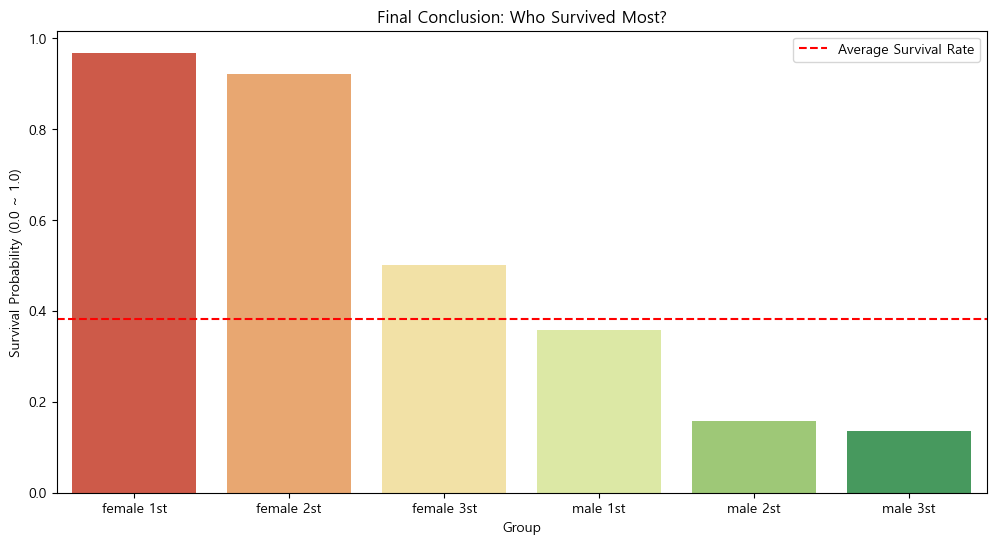

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화를 위해 '성별'과 '등급'을 합친 임시 컬럼을 하나 만듭니다. (이해하기 쉽게!)
# 자바로 치면 "Female" + " 1st" 같은 문자열 더하기입니다.
df['Group'] = df['Sex'] + " " + df['Pclass'].astype(str) + "st"

# 2. 그룹별로 평균 생존율을 계산해서 정렬합니다.
# 생존율이 높은 순서대로 보기 위함입니다.
group_survival = df.groupby('Group')['Survived'].mean().sort_values(ascending=False)

# 3. 그래프 그리기 (배운 Bar Chart 활용)
plt.figure(figsize=(12, 6))
sns.barplot(x=group_survival.index, y=group_survival.values, palette='RdYlGn') # 초록색일수록 생존율 높음

# 4. 전체 평균 선 긋기 (기준점)
plt.axhline(df['Survived'].mean(), color='red', linestyle='--', label='Average Survival Rate')

plt.title('Final Conclusion: Who Survived Most?')
plt.ylabel('Survival Probability (0.0 ~ 1.0)')
plt.legend()
plt.show()

# 사용이 끝난 임시 컬럼은 삭제 (데이터 무결성 유지)
df.drop(columns=['Group'], inplace=True)